# Exploratory Data Analysis & Hypothesis Testing

This section initiates the exploratory data analysis (EDA) to investigate key relationships within the King County housing dataset. The objective is to validate the formulated hypotheses and identify meaningful patterns that explain variations in house prices.

The analysis focuses on understanding price dependencies across different property characteristics in order to derive data-driven insights for a potential purchase recommendation for the buyer persona Nicole Johnson. In this context, relationships between housing features are examined to support a structured decision-making approach and to identify properties that meet defined criteria.

To achieve this, the analysis is organized into four main dimensions: price drivers (such as living area, renovation status, and grade), location effects (including ZIP code, waterfront access, and spatial patterns), property structure (such as house age, living-to-lot ratio, floors, and basement), and temporal effects (including monthly sales volume and price variation over time).

Based on these dimensions, the following **hypotheses** are tested:

1. **Size**: There is a positive relationship between sqft_living and house price.  
2. **Location effect**: House prices vary significantly across locations, with central and waterfront ZIP codes showing higher price levels than outer regions.  
3. **Quality**: Higher construction quality (grade) and better property condition are associated with higher house prices.  
4. **Property structure**: Property structure variables such as house age and living-to-lot ratio influence house prices and reflect differences in housing density and development stage.  
5. **Seasonal demand**: Property sales volume varies across months, indicating potential seasonal patterns in housing demand.


## Analysis

In [11]:
# importing raw data
import pandas as pd

df = pd.read_csv('king_county_housing_data.csv')

### Determine the Mid-range-price

In [12]:
mid_range_df = df[
    (df["price"] >= df["price"].quantile(0.25)) &
    (df["price"] <= df["price"].quantile(0.75))
]

In [13]:
mid_range = df[(df["price"] >= 322000) & (df["price"] <= 645000)]

### Hypothese 1: Size and House Price

This section examines the relationship between living area (sqft_living) and house price. The analysis investigates whether larger properties tend to achieve higher market prices, as expected in standard real estate valuation models.

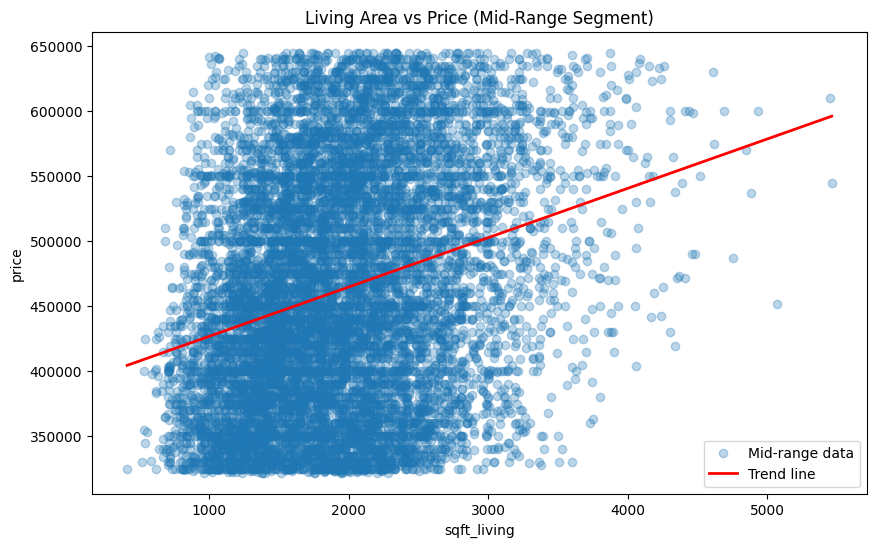

In [14]:
import numpy as np
import matplotlib.pyplot as plt

x = mid_range["sqft_living"]
y = mid_range["price"]

# linear model
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10,6))

plt.scatter(x, y, alpha=0.3, label="Mid-range data")

# sort for trendline
sorted_idx = np.argsort(x)
plt.plot(
    x.iloc[sorted_idx],
    (m*x + b).iloc[sorted_idx],
    color="red",
    linewidth=2,
    label="Trend line"
)

plt.title("Living Area vs Price (Mid-Range Segment)")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.legend()

plt.show()

### Interpretation Hypothese 1

✅ **hypothesis is supported**: Restricting the analysis to the mid-range price segment confirms a clear positive relationship between living area and house price. By excluding extreme luxury properties, the underlying trend becomes more stable and easier to interpret.

The relationship remains positive, indicating that even within the mid-market segment, property size is a key driver of price variation. However, some dispersion still exists, suggesting that additional factors such as location and property quality continue to influence pricing.

### Hypothese 2: Location Effect

This section analyzes how house prices vary across different locations. It focuses on ZIP codes and waterfront properties to assess whether central or waterfront locations are associated with higher price levels compared to outer regions.


<Figure size 1600x600 with 0 Axes>

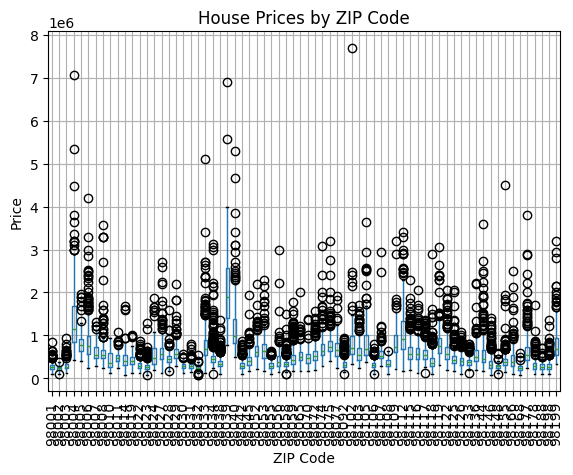

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

df.boxplot(column="price", by="zipcode", rot=90)

plt.title("House Prices by ZIP Code")
plt.suptitle("")  # remove automatic title
plt.xlabel("ZIP Code")
plt.ylabel("Price")

plt.show()

The boxplot reveals strong differences in house prices across ZIP codes. Some locations show significantly higher median prices and wider price ranges, indicating the presence of both standard and high-end properties.

At the same time, several ZIP codes display more compact distributions with lower price levels, suggesting more homogeneous and affordable housing markets. The variability across locations highlights that geographic position is a key determinant of price formation in the dataset.

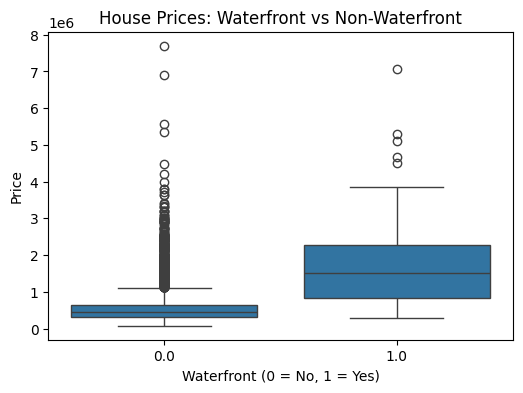

In [16]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="waterfront", y="price", data=df)

plt.title("House Prices: Waterfront vs Non-Waterfront")
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Price")

plt.show()

Properties with waterfront access show substantially higher price levels compared to non-waterfront houses. This confirms a strong location premium associated with direct water proximity, which significantly increases property value.

### Interpretation  Hypothese 2

✅ **The hypothesis is supported**: House prices vary significantly across locations, with both ZIP code differences and waterfront access having a strong impact on property value. Location is therefore a key driver of price variation in the housing market.

### Hypothese 3: Quality Effect

This section explores the impact of construction quality, condition, and renovation status on house prices. The goal is to determine whether higher quality properties systematically achieve higher market values.


<Figure size 1000x600 with 0 Axes>

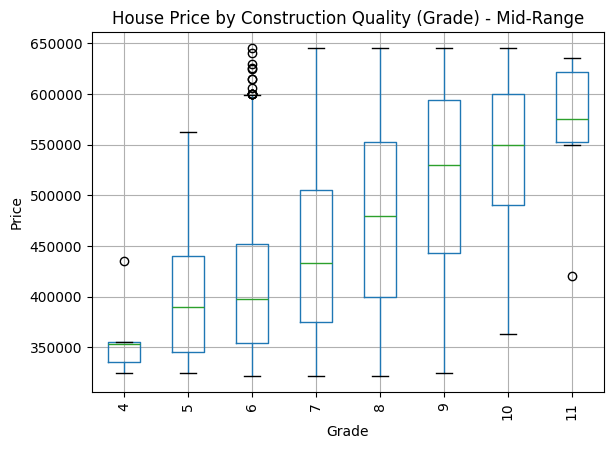

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

mid_range.boxplot(column="price", by="grade", rot=90)

plt.title("House Price by Construction Quality (Grade) - Mid-Range")
plt.suptitle("")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

Construction quality (grade) shows a clear relationship with house price within the mid-range segment. Higher grade values are generally associated with higher median prices, indicating that structural quality remains a strong price driver even outside the luxury segment.

At the same time, price variability increases at higher grade levels, suggesting that additional factors such as location and property characteristics influence pricing.

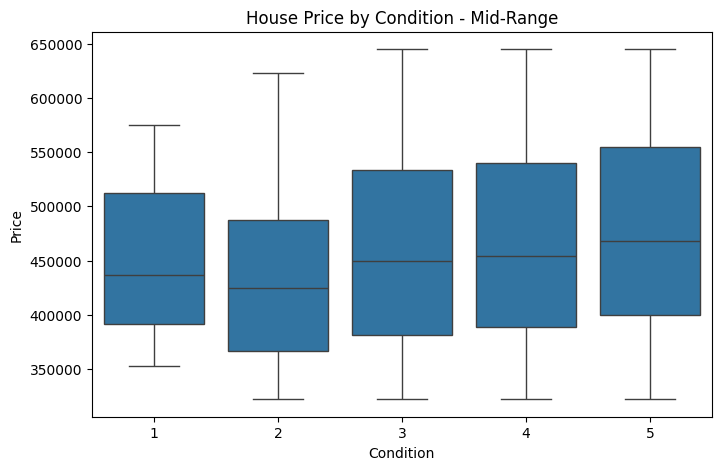

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x="condition", y="price", data=mid_range)

plt.title("House Price by Condition - Mid-Range")
plt.xlabel("Condition")
plt.ylabel("Price")

plt.show()

Property condition shows a moderate but consistent relationship with price. Better condition ratings are generally associated with higher prices, although the effect is less pronounced compared to construction quality (grade).

This suggests that condition acts as a secondary quality indicator rather than a primary price driver.

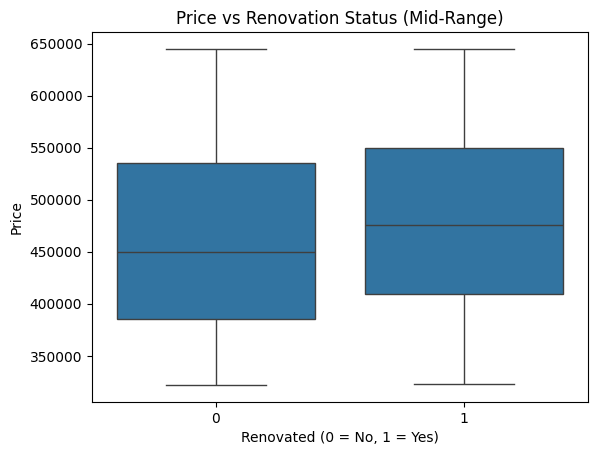

In [19]:
mid_range_df = df[
    (df["price"] >= df["price"].quantile(0.25)) &
    (df["price"] <= df["price"].quantile(0.75))
].copy()

mid_range_df["renovation_score"] = (mid_range_df["yr_renovated"] > 0).astype(int)

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="renovation_score", y="price", data=mid_range_df)

plt.title("Price vs Renovation Status (Mid-Range)")
plt.xlabel("Renovated (0 = No, 1 = Yes)")
plt.ylabel("Price")

plt.show()

Renovated properties tend to have higher median prices compared to non-renovated houses within the mid-range segment. However, the effect is less dominant than construction quality, indicating that renovation status contributes to price differences but does not solely determine value.

### Interpretation  Hypothese 3

✅ **The hypothesis is partially to fully supported**: Construction quality (grade) is the strongest quality-related price driver, followed by condition and renovation status. Even within the mid-range segment, property quality significantly influences house prices, although its effect is moderated by other factors such as location and structure.

### Hypothese 4: Property Structure

This section investigates structural property characteristics such as house age and the living-to-lot ratio. It aims to understand how building age and land utilization relate to differences in housing prices and density patterns.


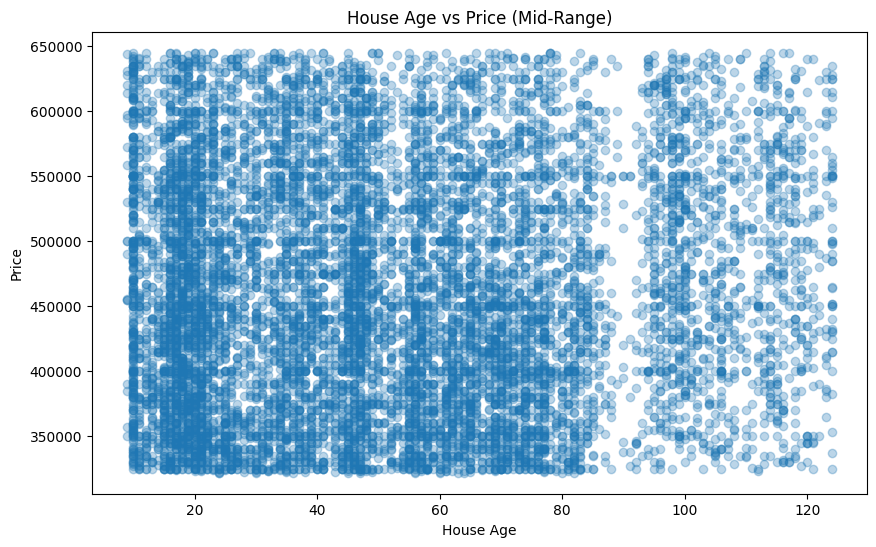

In [ ]:
mid_range_df["house_age"] = 2024 - mid_range_df["yr_built"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(mid_range_df["house_age"], mid_range_df["price"], alpha=0.3)

plt.title("House Age vs Price (Mid-Range)")
plt.xlabel("House Age")
plt.ylabel("Price")

plt.show()

House age shows a weak to moderate relationship with price within the mid-range segment. Newer houses tend to achieve slightly higher prices, although the relationship is not strictly linear.

The dispersion suggests that age alone is not a dominant price driver and is strongly influenced by other factors such as location and property quality.

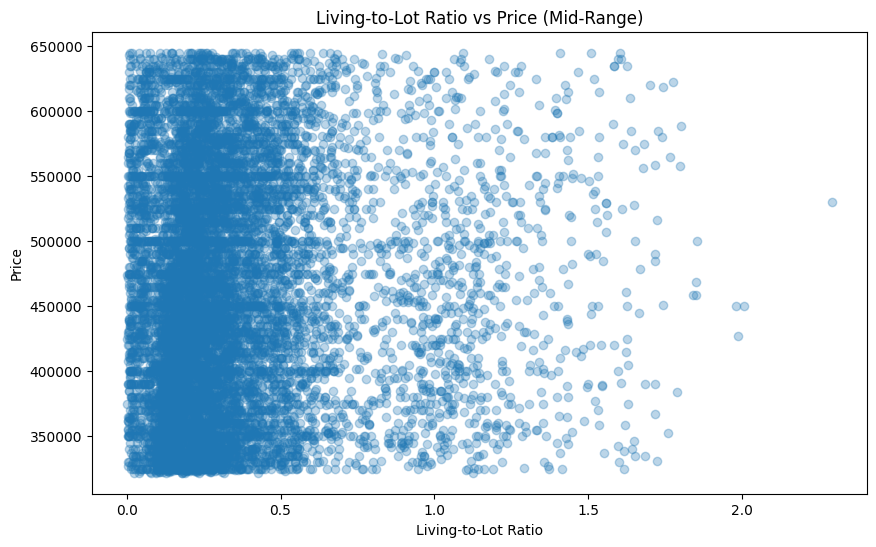

In [23]:
import matplotlib.pyplot as plt

# Sicherheit: Spalte existiert
if "living_to_lot_ratio" not in mid_range_df.columns:
    mid_range_df["living_to_lot_ratio"] = (
        mid_range_df["sqft_living"] / mid_range_df["sqft_lot"]
    )

plt.figure(figsize=(10,6))

plt.scatter(
    mid_range_df["living_to_lot_ratio"],
    mid_range_df["price"],
    alpha=0.3
)

plt.title("Living-to-Lot Ratio vs Price (Mid-Range)")
plt.xlabel("Living-to-Lot Ratio")
plt.ylabel("Price")

plt.show()

The living-to-lot ratio shows a weak but visible relationship with price. Higher density properties tend to have slightly higher prices, although the relationship is not strongly linear.

The high variability indicates that land utilization alone is not a primary pricing factor but may contribute in combination with location and property quality.

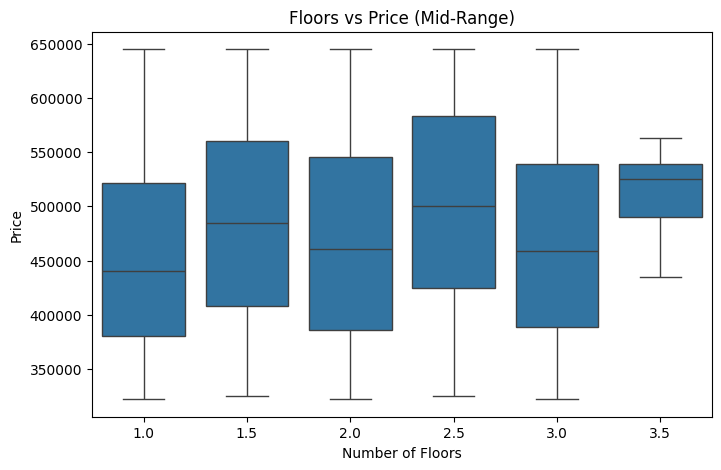

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x="floors", y="price", data=mid_range_df)

plt.title("Floors vs Price (Mid-Range)")
plt.xlabel("Number of Floors")
plt.ylabel("Price")

plt.show()

The number of floors shows only a weak relationship with price in the mid-range segment. While slightly higher prices can be observed for multi-story properties, the effect is not strong or consistent.

This suggests that vertical structure is not a primary pricing driver compared to size, location, or quality.

### Interpretation  Hypothese 4

🔁 **Hypothesis is only partially supported.** Property structure variables such as house age, living-to-lot ratio, and number of floors show some influence on house prices, but none of them act as strong standalone predictors. Instead, they contribute as secondary factors in combination with location and property quality.

### Hypothese 5: Seasonal Supply

This section examines whether property sales volumes vary across months. The analysis explores potential seasonal patterns in market activity and supply fluctuations over time.

In [26]:
import pandas as pd

mid_range_df = df[
    (df["price"] >= df["price"].quantile(0.25)) &
    (df["price"] <= df["price"].quantile(0.75))
].copy()

mid_range_df["date"] = pd.to_datetime(mid_range_df["date"])
mid_range_df["month_name"] = mid_range_df["date"].dt.month_name()

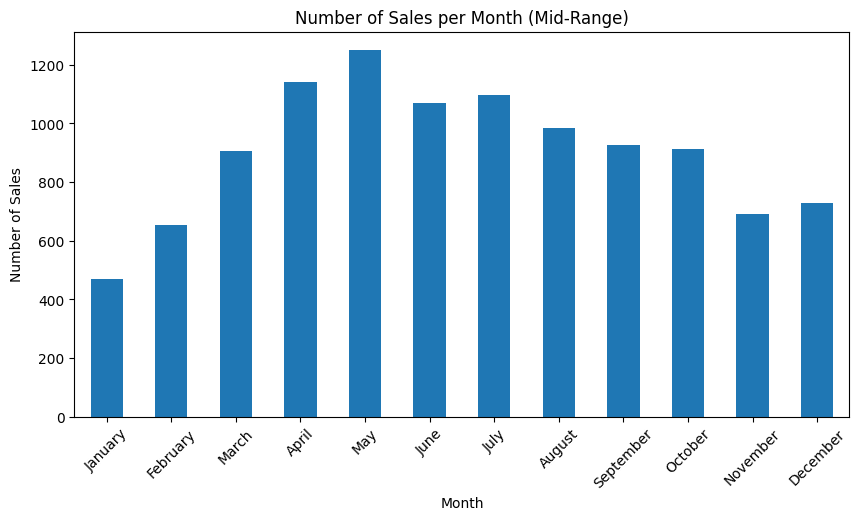

In [27]:
import matplotlib.pyplot as plt

order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(10,5))

mid_range_df["month_name"].value_counts().reindex(order).plot(kind="bar")

plt.title("Number of Sales per Month (Mid-Range)")
plt.xlabel("Month")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)

plt.show()

Sales volume shows moderate variation across months, suggesting the presence of seasonal fluctuations in housing market activity. Some months exhibit higher transaction counts, indicating periods of increased market activity, while others show lower demand.

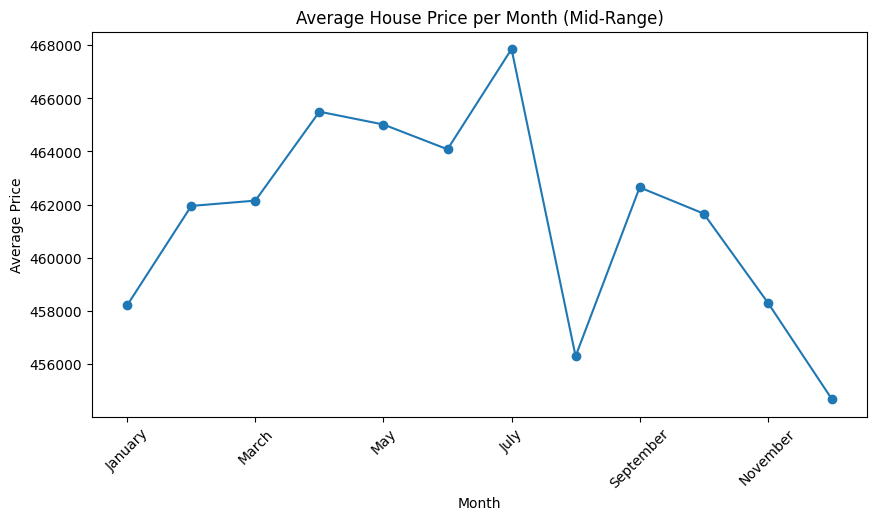

In [28]:
import numpy as np

avg_price = mid_range_df.groupby("month_name")["price"].mean().reindex(order)

plt.figure(figsize=(10,5))
avg_price.plot(marker="o")

plt.title("Average House Price per Month (Mid-Range)")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()

Average house prices vary slightly across months, but no strong or consistent seasonal trend is visible. While some months show higher average prices, the variation remains relatively moderate, suggesting that seasonality has a limited effect on pricing compared to structural and location-based factors.

### Interpretation  Hypothese 5

✅ **The hypothesis is only partially supported:** While sales volume shows some seasonal variation, indicating fluctuations in market activity, house prices remain relatively stable across months. Therefore, seasonality appears to influence demand timing more than price levels.

In [ ]:
# setting a score for density - asked chatGPT how to do it

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

radius_km = 1

densities = []

‚for i, row in rel_df.iterrows():
    lat, lon = row["lat"], row["long"]
    
    # 🔹 Step 1: fast bounding box filter (~1km ≈ 0.01 degrees)
    subset = rel_df[
        (rel_df["lat"].between(lat - 0.02, lat + 0.02)) &
        (rel_df["long"].between(lon - 0.02, lon + 0.02))
    ]
    
    # 🔹 Step 2: exact distances
    distances = haversine(
        lat,
        lon,
        subset["lat"].values,
        subset["long"].values
    )
    
    # 🔹 Step 3: count neighbors
    count = np.sum(distances <= radius_km) - 1  # exclude itself
    
    densities.append(count)

rel_df["housing_density_1km"] = densities

NameError: name 'rel_df' is not defined

In [ ]:
rel_df["density_per_km2"] = rel_df["housing_density_1km"] / (np.pi * 1**2)
rel_df["density_per_km2"]
bins = ["low","medium", "high","very high"]
rel_df["density"] = pd.cut(rel_df["density_per_km2"], bins=4, labels=[1,2, 3,4])
rel_df.head()

import seaborn as sns

sns.pairplot(data=rel_df, corner=True)

In [ ]:
np.mean(rel_df["price"])
rel_df[rel_df["density"]==4]["zipcode"].plot(kind="hist", bins=20, xticks=rel_df[rel_df["density"]==4]["zipcode"].unique())
rel_df[rel_df["density"]==4]["zipcode"].value_counts()
rel_df[rel_df["density"]==4]["zipcode"].unique()

In [ ]:
# started to try to create scatter plot of only the highest density zipcodes and wanted to see only those buildings with below Mean pricing, but running into errors...

df_sub = rel_df[rel_df["zipcode"] == rel_df[rel_df["density"]==4]["zipcode"].unique()]
rel_df.loc[([rel_df["density"]==4]) & (rel_df["price"]<540296.57)]

In [ ]:
#full scatterplot of all houses in our list
import matplotlib.pyplot as plt


plt.figure(figsize=(14,6))
plt.scatter(df_stu["long"], df_stu["lat"])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Locations")
plt.show()

In [ ]:
#dataprep for later manipulation & transformation
# various price/quality relations and timing relations regarding ideal time of sale

rel_df["month"] = rel_df['date'].dt.month
rel_df["quarter"] = rel_df['date'].dt.quarter

import numpy as np

rel_df["season"]=np.nan

# Spring = March till june / Summer = June till September /  Fall = september till December/ Winter = December till March
for i, month in enumerate(rel_df["month"]):
    if month in [3, 4, 5]:
        rel_df["season"][i]= "Spring"
    elif month in [6, 7, 8]:
        rel_df["season"][i]= "Summer"
    elif month in [9, 10, 11]:
        rel_df["season"][i]= "Fall"
    else:
        rel_df["season"][i]= "Winter"
rel_df.head(10)

In [ ]:

#dataprep for later manipulation & transformation
# various price/quality relations and timing relations regarding ideal time of sale

rel_df["month"] = rel_df['date'].dt.month
rel_df["quarter"] = rel_df['date'].dt.quarter

import numpy as np

rel_df["season"]=np.nan

# Spring = March till june / Summer = June till September /  Fall = september till December/ Winter = December till March
for i, month in enumerate(rel_df["month"]):
    if month in [3, 4, 5]:
        rel_df["season"][i]= 1
    elif month in [6, 7, 8]:
        rel_df["season"][i]= 2
    elif month in [9, 10, 11]:
        rel_df["season"][i]= 3
    else:
        rel_df["season"][i]= 4
rel_df.head(10)

## Ideal Property for Nicole

In [ ]:
ideal_houses = mid_range[
    (mid_range["sqft_living"] >= 1400) &
    (mid_range["sqft_living"] <= 2200)
]

ideal_houses.shape

In [ ]:
filtered = df[
    (df["price"] >= 322000) &
    (df["price"] <= 645000) &
    (df["sqft_living"] >= 1400) &
    (df["sqft_living"] <= 2200) &
    (df["grade"] >= 7) &
    (df["grade"] <= 8) &
    (df["waterfront"] == 0)
]

In [ ]:

scored = filtered.copy()

# Size Score
scored["size_score"] = (scored["sqft_living"] - 1400) / (2200 - 1400)

# 2. Grade Score
scored["grade_score"] = (scored["grade"] - 7) / (8 - 7)

# 3. Renovation Score
scored["reno_score"] = scored["yr_renovated"].notna().astype(int)

# 4. Price Score
median_price = scored["price"].median()
scored["price_score"] = 1 - abs(scored["price"] - median_price) / median_price

# 5. Total Score
scored["final_score"] = (
    0.25 * scored["size_score"] +
    0.25 * scored["grade_score"] +
    0.20 * scored["reno_score"] +
    0.30 * scored["price_score"]
)

In [ ]:
top_properties.shape

In [ ]:
top_properties = scored.sort_values("final_score", ascending=False).head(10)
top_properties

In [ ]:
import matplotlib.pyplot as plt

# Basis: all properties
plt.figure(figsize=(45, 15))
plt.scatter(df["long"], df["lat"], alpha=0.3, label="All Houses")

# Top properties for Nicole
selected = top_properties  # oder scored.nlargest(50, "final_score")

plt.scatter(
    selected["long"],
    selected["lat"],
    color="red",
    alpha=1,
    label="Optimal Houses (Nicole)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Locations with Optimal Matches Highlighted")
plt.legend()

plt.show()

...